In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Iteration 0: Loss = 229.2339
Iteration 100: Loss = 2.0018
Iteration 200: Loss = 1.8763
Iteration 300: Loss = 1.8350
Iteration 400: Loss = 1.8215
Iteration 500: Loss = 1.8170
Iteration 600: Loss = 1.8155
Iteration 700: Loss = 1.8151
Iteration 800: Loss = 1.8149
Iteration 900: Loss = 1.8148

Trained weights: 2.4319
Trained bias: 1.8172
R² Score: 0.9661


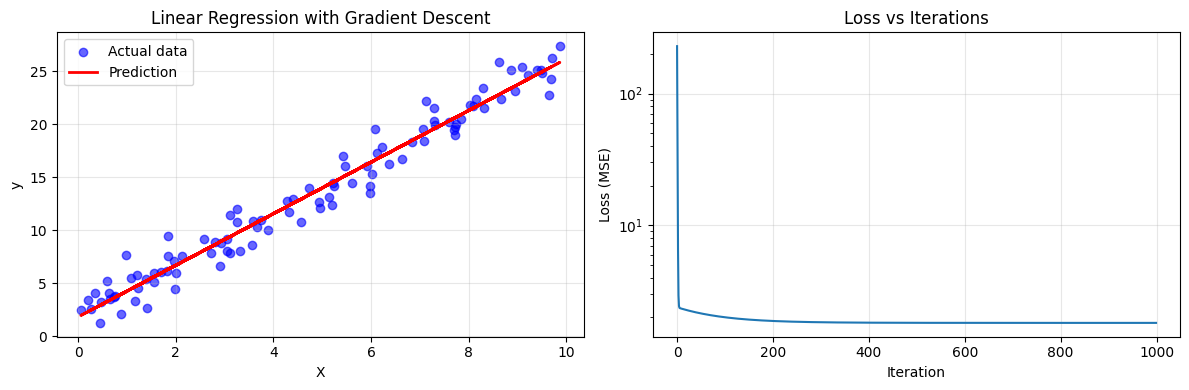

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        """
        Initialize the Linear Regression model with Gradient Descent
        
        Parameters:
        learning_rate: Step size for gradient descent
        n_iterations: Number of iterations for training
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []
        
    def fit(self, X, y):
        """
        Train the model using gradient descent
        
        Parameters:
        X: Training features (n_samples, n_features)
        y: Training targets (n_samples,)
        """
        n_samples, n_features = X.shape
        
        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Gradient descent
        for i in range(self.n_iterations):
            # Forward pass: predict
            y_predicted = np.dot(X, self.weights) + self.bias
            
            # Calculate loss (MSE)
            loss = np.mean((y - y_predicted) ** 2)
            self.loss_history.append(loss)
            
            # Calculate gradients
            dw = -(2/n_samples) * np.dot(X.T, (y - y_predicted))
            db = -(2/n_samples) * np.sum(y - y_predicted)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Optional: print progress every 100 iterations
            if i % 100 == 0:
                print(f"Iteration {i}: Loss = {loss:.4f}")
    
    def predict(self, X):
        """Make predictions"""
        return np.dot(X, self.weights) + self.bias
    
    def score(self, X, y):
        """Calculate R² score"""
        y_pred = self.predict(X)
        ss_total = np.sum((y - np.mean(y)) ** 2)
        ss_residual = np.sum((y - y_pred) ** 2)
        return 1 - (ss_residual / ss_total)

# Generate sample data
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # 100 samples, 1 feature
y = 2.5 * X.squeeze() + 1.5 + np.random.randn(100) * 1.5  # y = 2.5x + 1.5 + noise

# Create and train the model
model = LinearRegressionGD(learning_rate=0.01, n_iterations=1000)
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Print results
print(f"\nTrained weights: {model.weights[0]:.4f}")
print(f"Trained bias: {model.bias:.4f}")
print(f"R² Score: {model.score(X, y):.4f}")

# Plot results
plt.figure(figsize=(12, 4))

# Plot 1: Data and regression line
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Prediction')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression with Gradient Descent')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Loss history
plt.subplot(1, 2, 2)
plt.plot(model.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.title('Loss vs Iterations')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()